**Predicting AAPL Stock Return Direction Using Machine Learning**

## Introduction

Stock market prediction is a widely studied problem in finance and machine learning. The goal of this project is to determine whether machine learning models can predict the short-term direction of stock price movements.

Specifically, this project focuses on predicting whether Apple (AAPL) stock will increase or decrease in price on the next trading day using historical stock data.

This project follows a full predictive analytics workflow, including data cleaning, feature engineering, model building, and evaluation.

## Dataset

The dataset used in this project comes from Kaggle and contains historical stock price data for companies in the S&P 500 index.

The dataset includes the following variables:
- Date
- Open price
- High price
- Low price
- Close price
- Trading volume
- Stock ticker (Name)

For this analysis, the dataset was filtered to focus specifically on Apple (AAPL) stock to ensure consistency in modeling.

In [3]:
import pandas as pd
import os

# Check what files are inside the dataset folder
os.listdir(path)

['merge.sh', 'getSandP.py', 'individual_stocks_5yr', 'all_stocks_5yr.csv']

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/sandp500")

print("Path to dataset files:", path)

100%|██████████| 19.3M/19.3M [00:01<00:00, 11.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/camnugent/sandp500/versions/4


In [4]:
df = pd.read_csv(path + '/all_stocks_5yr.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [5]:
# Create tomorrow's closing price
df['Tomorrow_Close'] = df['close'].shift(-1)

# Create target variable
df['Target'] = (df['Tomorrow_Close'] > df['close']).astype(int)

# Drop last row
df = df.dropna()

## Data Preprocessing

The dataset was cleaned and prepared for analysis by performing the following steps:

- Filtering the dataset to include only AAPL stock
- Sorting the data by date to maintain chronological order
- Creating a target variable that indicates whether the stock price increased or decreased the next day
- Removing missing values created during shifting and rolling calculations

These steps ensure that the dataset is properly structured for time series modeling.

In [6]:
df = df[df['Name'] == 'AAPL']  # you can change to any stock
df = df.sort_values('date')
df.head()

,date,open,high,low,close,volume,Name,Tomorrow_Close,Target
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,68.5614,1
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,66.8428,0
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,66.7156,0
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,66.6556,0
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,65.7371,0


## Feature Engineering

Several features were created to capture important financial patterns:

- Daily Return: Measures the percentage change in price from one day to the next
- Moving Averages (MA5 and MA10): Capture short-term price trends
- Volatility: Measures the variability of stock prices over time
- Volume Change: Tracks changes in trading activity

These features help the model identify patterns related to momentum, trends, and market behavior.

In [7]:
# Daily return
df['Return'] = df['close'].pct_change()

# Moving averages
df['MA5'] = df['close'].rolling(window=5).mean()
df['MA10'] = df['close'].rolling(window=10).mean()

# Volatility
df['Volatility'] = df['close'].rolling(window=5).std()

# Volume change
df['Volume_Change'] = df['volume'].pct_change()

# Drop missing values
df = df.dropna()

df.head()

,date,open,high,low,close,volume,Name,Tomorrow_Close,Target,Return,MA5,MA10,Volatility,Volume_Change
1268,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL,63.2571,0,0.010649,64.73910,66.03251,0.931740,-0.259981
1269,2013-02-25,64.8356,65.0171,63.2242,63.2571,92899597,AAPL,64.1385,1,-0.017768,64.24310,65.57280,0.927739,0.124913
1270,2013-02-26,63.4028,64.5056,62.5228,64.1385,125096657,AAPL,63.5099,0,0.013934,63.92824,65.13051,0.446664,0.346579
1271,2013-02-27,64.0614,64.6342,62.9499,63.5099,146674682,AAPL,63.0571,0,-0.009801,63.80594,64.79722,0.463936,0.172491
1272,2013-02-28,63.4357,63.9814,63.0571,63.0571,80532382,AAPL,61.4957,0,-0.007130,63.67280,64.43137,0.575796,-0.450946


In [8]:
from sklearn.model_selection import train_test_split

# Features (X)
X = df[['Return', 'MA5', 'MA10', 'Volatility', 'Volume_Change']]

# Target (y)
y = df['Target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## Modeling

Two machine learning models were used to predict stock price direction:

1. Logistic Regression:
   A simple baseline model used for binary classification.

2. Random Forest:
   A more complex model that can capture nonlinear relationships in the data.

The dataset was split into training and testing sets using an 80/20 split, without shuffling, to preserve the time series structure.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

accuracy = accuracy_score(y_test, preds)
print("Accuracy:", accuracy)

Accuracy: 0.484


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.508


## Results

The performance of the models was evaluated using accuracy.

- Logistic Regression Accuracy: 48.4%
- Random Forest Accuracy: 50.8%

The Random Forest model performed slightly better, but both models achieved accuracy levels close to random guessing.

## Feature Importance

The Random Forest model provides insight into which features are most important for prediction.

The results show that:
- Volume Change
- Daily Return
- Volatility

are the most influential variables in determining stock movement direction.

This suggests that both trading activity and recent price behavior play key roles in prediction.

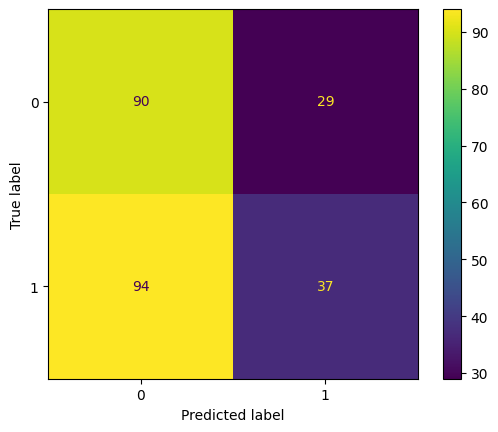

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Model Evaluation (Confusion Matrix)

The confusion matrix provides insight into how well the model predicts each class (up vs down).

The results show that the model struggles to correctly predict upward movements, indicating a limitation in capturing short-term market changes.

In [12]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
4,Volume_Change,0.203899
0,Return,0.202360
3,Volatility,0.199431
1,MA5,0.197587
2,MA10,0.196723


## Exploratory Data Analysis (EDA)

The following plot shows the historical closing price of Apple (AAPL) stock over time.

From the graph, we can observe an overall upward trend in the stock price, with periods of volatility and short-term fluctuations. These fluctuations highlight the dynamic nature of financial markets and the challenges associated with predicting short-term price movements.

Understanding these trends is important for building predictive models, as it provides insight into momentum, volatility, and potential patterns in the data.

<Axes: title={'center': 'AAPL Stock Price Over Time'}>

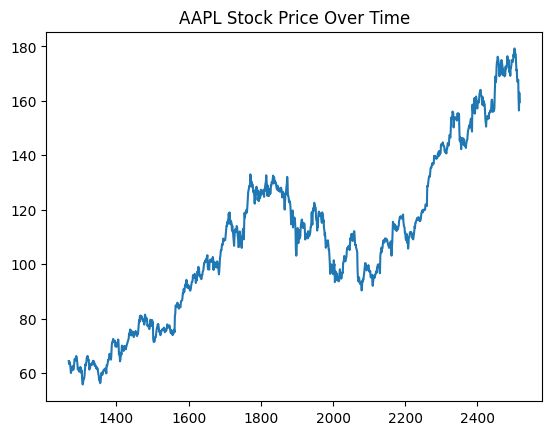

In [13]:
df['close'].plot(title='AAPL Stock Price Over Time')

## Insights and Conclusion

The results indicate that predicting short-term stock price movements is highly challenging. Both models performed close to 50% accuracy, which suggests that the models are not significantly better than random guessing.

This finding aligns with the Efficient Market Hypothesis, which states that stock prices reflect all available information, making it difficult to consistently predict future movements.

Although the models did not achieve high accuracy, they demonstrate the full predictive analytics process and highlight the complexity of financial markets.

These models may still provide value when combined with other financial analysis tools, but should not be relied upon alone for investment decisions.

## Ethical Considerations

Using machine learning models in financial decision-making can have ethical implications.

If models are inaccurate or misinterpreted, they could lead to poor investment decisions and financial loss. Additionally, overreliance on automated predictions may reduce critical thinking and human judgment.

It is important to use these models responsibly and understand their limitations.